In [3]:
import pandas as pd

df = pd.read_csv('ufo_final.csv')
print(df.shape)
df.head()

(1174, 3)


,Location,UFO_shape,length_of_encounter_seconds
0,gb | Unknown | leicester (uk/england),fireball,60.0
1,us | wa | spokane,triangle,180.0
2,gb | Unknown | colchester (uk/england),cigar,420.0
3,us | pa | norristown,disk,3600.0
4,us | mi | troy,light,5.0


In [ ]:
# MISSING VALUES

In [4]:
df['Location'] = df['Location'].fillna('Unknown | Unknown | Unknown')

print('Missing Location values now:', df['Location'].isna().sum())

Missing Location values now: 0


In [ ]:
# location into country state and city

In [5]:
loc_parts = df['Location'].str.split(' | ', expand=True, regex=False)

df['country'] = loc_parts[0].str.strip()
df['state']   = loc_parts[1].str.strip()
df['city']    = loc_parts[2].str.strip()

df[['Location', 'country', 'state', 'city']].head()

,Location,country,state,city
0,gb | Unknown | leicester (uk/england),gb,Unknown,leicester (uk/england)
1,us | wa | spokane,us,wa,spokane
2,gb | Unknown | colchester (uk/england),gb,Unknown,colchester (uk/england)
3,us | pa | norristown,us,pa,norristown
4,us | mi | troy,us,mi,troy


In [ ]:
# CLASSES OF CITIES

In [6]:
city_counts = df['city'].value_counts()
print('Total unique cities:', df['city'].nunique())
print('Cities that appear only once:', (city_counts == 1).sum())

# Keep the top 15 most common cities, group the rest into 'Other'
top_cities = city_counts.nlargest(15).index
df['city_class'] = df['city'].apply(lambda x: x if x in top_cities else 'Other')

df['city_class'].value_counts()

Total unique cities: 820
Cities that appear only once: 684


city_class
Other          966
Unknown        133
los angeles      9
chicago          8
las vegas        6
san diego        6
richmond         5
lancaster        5
st. louis        5
phoenix          5
seattle          5
san antonio      5
paradise         4
orlando          4
wilmington       4
tucson           4
Name: count, dtype: int64

In [ ]:
## UFO columns into 0s and 1s (one-hot encoding)

In [31]:
df_encoded = pd.get_dummies(df, columns=['UFO_shape', 'city_class'], drop_first=False)

# True/False by default — convert those to 1/0
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(df_encoded.shape)
df_encoded.head()

(1174, 42)


,Location,length_of_encounter_seconds,country,state,city,UFO_shape_changing,UFO_shape_chevron,UFO_shape_cigar,UFO_shape_circle,UFO_shape_cone,...,city_class_orlando,city_class_paradise,city_class_phoenix,city_class_richmond,city_class_san antonio,city_class_san diego,city_class_seattle,city_class_st. louis,city_class_tucson,city_class_wilmington
0,gb | Unknown | leicester (uk/england),60.0,gb,Unknown,leicester (uk/england),0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,us | wa | spokane,180.0,us,wa,spokane,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,gb | Unknown | colchester (uk/england),420.0,gb,Unknown,colchester (uk/england),0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,us | pa | norristown,3600.0,us,pa,norristown,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,us | mi | troy,5.0,us,mi,troy,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df_encoded.to_csv('ufo_encoded_final.csv', index=False)
print('Saved: ufo_encoded_final.csv')

Saved: ufo_encoded_final.csv


In [ ]:
# RESULT

In [9]:
result = (
    df.groupby('city_class')
    .agg(
        num_sightings=('UFO_shape', 'count'),
        most_common_shape=('UFO_shape', lambda x: x.value_counts().idxmax()),
        avg_duration_seconds=('length_of_encounter_seconds', 'mean'),
        median_duration_seconds=('length_of_encounter_seconds', 'median'),
    )
    .sort_values('num_sightings', ascending=False)
    .reset_index()
)

result['avg_duration_seconds'] = result['avg_duration_seconds'].round(0)
result

,city_class,num_sightings,most_common_shape,avg_duration_seconds,median_duration_seconds
0,Other,966,light,1487.0,180.0
1,Unknown,133,light,81765.0,180.0
2,los angeles,9,other,139.0,120.0
3,chicago,8,light,82.0,52.5
4,las vegas,6,light,622.0,510.0
5,san diego,6,triangle,275.0,180.0
6,phoenix,5,unknown,246270.0,120.0
7,lancaster,5,light,127.0,30.0
8,seattle,5,light,303.0,12.0
9,st. louis,5,unknown,244.0,300.0


In [14]:
result.to_csv('ufo_result.csv', index=False)
print('Saved!')

Saved!


In [ ]:
# LOCATION X SHAPE

In [11]:
# Cross-tab: state vs shape (counts)
state_shape_crosstab = pd.crosstab(df['state'], df['UFO_shape'])
state_shape_crosstab

UFO_shape,changing,chevron,cigar,circle,cone,cross,cylinder,diamond,disk,egg,...,flash,formation,light,other,oval,rectangle,sphere,teardrop,triangle,unknown
state,,,,,,,,,,,,,,,,,,,,,
Unknown,1,2,3,19,2,0,1,3,9,4,...,3,6,31,12,10,2,12,1,22,14
ab,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,1
ak,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0
al,0,0,0,1,0,0,0,0,1,0,...,0,0,1,1,0,1,0,0,0,1
ar,1,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,3,0
az,1,0,0,2,0,0,1,0,1,0,...,0,2,11,1,1,0,4,1,7,2
bc,0,0,1,1,0,0,0,0,0,1,...,0,0,3,2,0,0,2,0,4,0
ca,4,0,3,10,0,1,2,4,9,2,...,3,4,28,10,6,2,7,1,11,10
co,2,0,1,5,0,0,0,0,2,0,...,0,0,6,2,2,0,3,0,4,3


In [17]:
ufo_result = result
(print(ufo_result))

     city_class  num_sightings most_common_shape  avg_duration_seconds  \
0         Other            966             light                1487.0   
1       Unknown            133             light               81765.0   
2   los angeles              9             other                 139.0   
3       chicago              8             light                  82.0   
4     las vegas              6             light                 622.0   
5     san diego              6          triangle                 275.0   
6       phoenix              5           unknown              246270.0   
7     lancaster              5             light                 127.0   
8       seattle              5             light                 303.0   
9     st. louis              5           unknown                 244.0   
10     richmond              5              disk                1032.0   
11  san antonio              5             cigar                1393.0   
12     paradise              4        

In [ ]:
#Visualization:

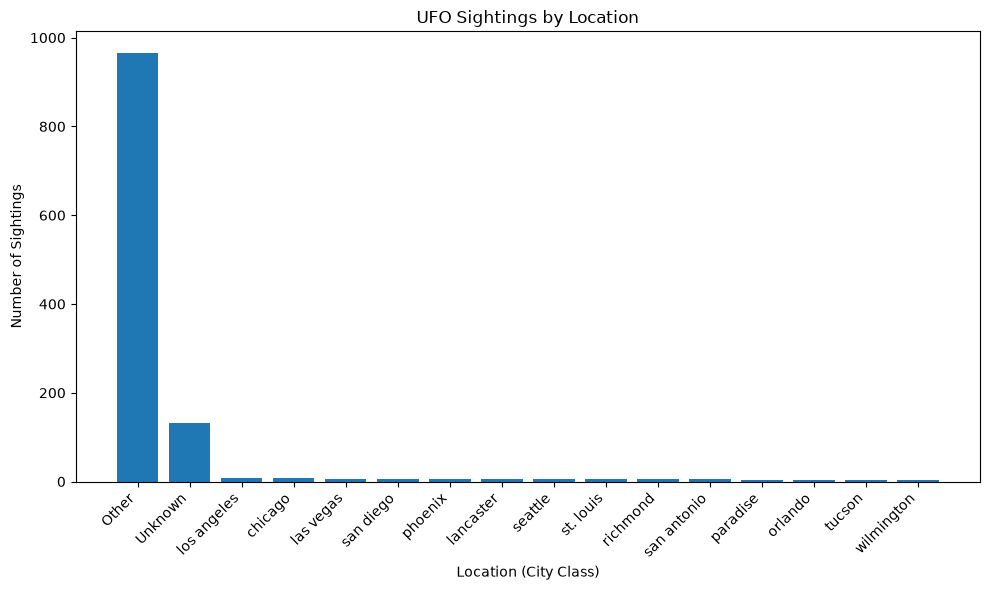

In [24]:
import matplotlib.pyplot as plt

result_sorted = result.sort_values("num_sightings", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(result_sorted["city_class"], result_sorted["num_sightings"])
plt.xlabel("Location (City Class)")
plt.ylabel("Number of Sightings")
plt.title("UFO Sightings by Location")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

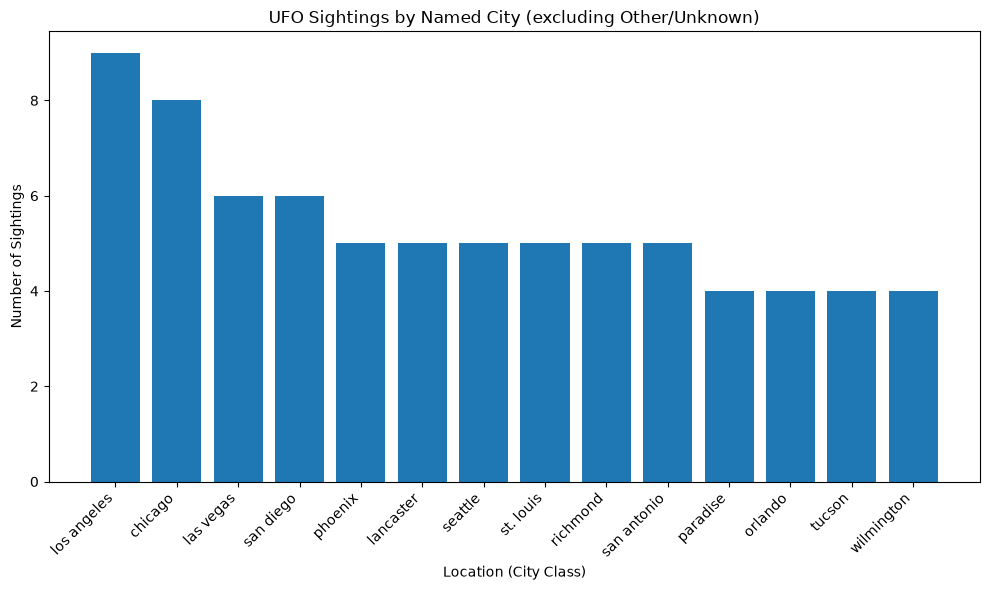

In [25]:
import matplotlib.pyplot as plt
#sorrt
result_sorted = result.sort_values("num_sightings", ascending=False)

result_no_other = result_sorted[~result_sorted["city_class"].isin(["Other", "Unknown"])]

plt.figure(figsize=(10, 6))
plt.bar(result_no_other["city_class"], result_no_other["num_sightings"])
plt.xlabel("Location (City Class)")
plt.ylabel("Number of Sightings")
plt.title("UFO Sightings by Named City (excluding Other/Unknown)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

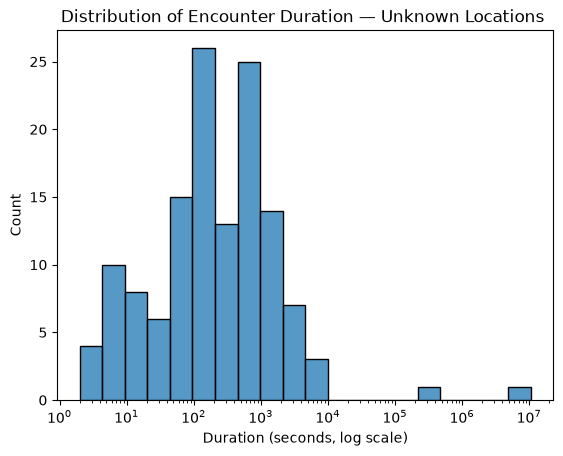

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=unknown_df, x="length_of_encounter_seconds", bins=20, log_scale=True)
plt.title("Distribution of Encounter Duration — Unknown Locations ")
plt.xlabel("Duration (seconds, log scale)")
plt.ylabel("Count")
plt.show()

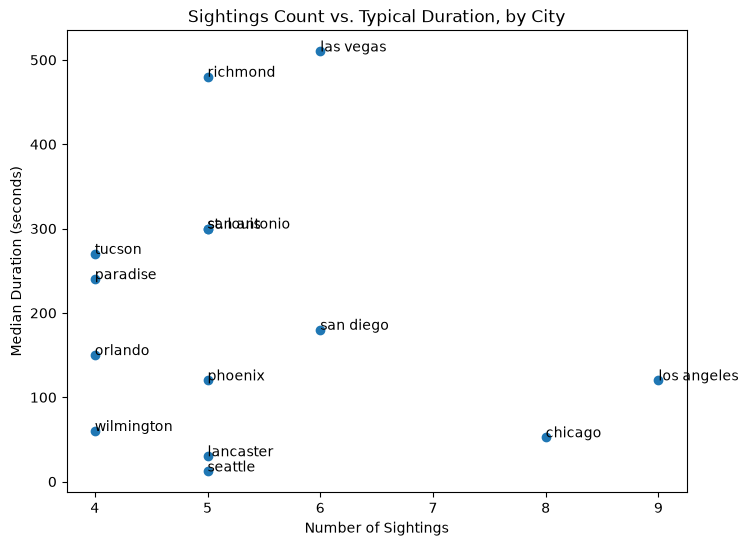

In [29]:
result_no_other = result[~result["city_class"].isin(["Other", "Unknown"])]

plt.figure(figsize=(8, 6))
plt.scatter(result_no_other["num_sightings"], result_no_other["median_duration_seconds"])

for i, row in result_no_other.iterrows():
    plt.annotate(row["city_class"], (row["num_sightings"], row["median_duration_seconds"]))

plt.xlabel("Number of Sightings")
plt.ylabel("Median Duration (seconds)")
plt.title("Sightings Count vs. Typical Duration, by City")
plt.show()

how many sightings a city has doesn't predict how long those sightings typically last.